In [1]:
from datasets import load_dataset



/opt/conda/envs/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load a dataset (replace 'emotion' with the dataset you want to load)
dataset = load_dataset('assoni2002/jailbreak_audio_train_data')

# You can explore the dataset
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['audio', 'labels'],
        num_rows: 4886
    })
})


In [21]:
dataset['train'][2]

{'audio': <datasets.features._torchcodec.AudioDecoder at 0x7ff4de1e4d90>,
 'labels': 1}

In [19]:
import pandas as pd

# 'audio_sample' is already an AudioDecoder object
audio_sample = dataset['train'][2]['audio']

audio_data = audio_sample.get_all_samples()

In [20]:
audio_data

AudioSamples:
  data (shape): torch.Size([1, 91009])
  pts_seconds: 0.0
  duration_seconds: 3.7920416666666665
  sample_rate: 24000

In [4]:
dataset_info = dataset['train'].info
print(dataset_info)

DatasetInfo(description='', citation='', homepage='', license='', features={'audio': Audio(sampling_rate=None, decode=True, stream_index=None), 'labels': Value('int64'), 'text': Value('string')}, post_processed=None, supervised_keys=None, builder_name='parquet', dataset_name='zscaler_tts_training_data', config_name='default', version=0.0.0, splits={'train': SplitInfo(name='train', num_bytes=435273950, num_examples=1544, shard_lengths=None, dataset_name='zscaler_tts_training_data')}, download_checksums={'hf://datasets/assoni2002/zscaler_tts_training_data@34459f2bac5e8bae1676c3180c5cb200fb8e8e99/data/train-00000-of-00001.parquet': {'num_bytes': 400138962, 'checksum': None}}, download_size=400138962, post_processing_size=None, dataset_size=435273950, size_in_bytes=835412912)


In [10]:
dataset['train'][0]

{'audio': <datasets.features._torchcodec.AudioDecoder at 0x7f48949c1e70>,
 'labels': 0}

In [ ]:
import collections

import matplotlib.pyplot as plt

# Extract sampling rates from all audio samples
sampling_rates = [sample['audio']['sampling_rate'] for sample in dataset['train']]

# Count occurrences of each sampling rate
rate_counts = collections.Counter(sampling_rates)


In [17]:
print(set(sampling_rates))

{24000}


ValueError: 'label' must be of length 'x'

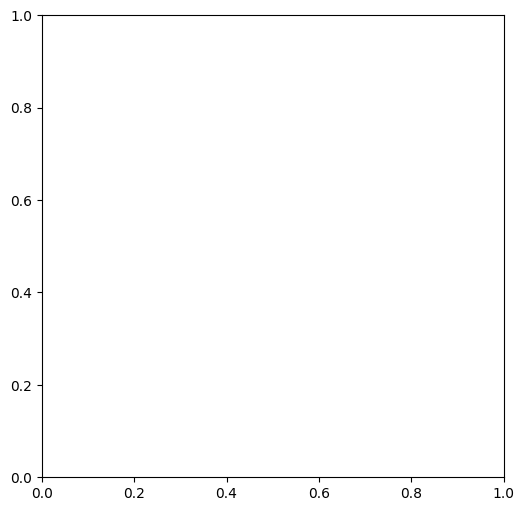

In [13]:
plt.figure(figsize=(6, 6))
plt.pie(sampling_rates, labels=rate_counts.keys(), autopct='%1.1f%%', startangle=90)
plt.title('Sampling Rate Distribution')
plt.show()